Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

Load the Scaled Dataset

In [2]:
X_scaled = pd.read_csv("../datasets/cleaned/customer_features_scaled.csv")

X_scaled.head()

,Recency,Frequency,Monetary,Total_Freight,Average_Product_Price,Total_Products,Average_Installments,Preferred_Payment_credit_card,Preferred_Payment_debit_card,Preferred_Payment_voucher
0,-0.825322,-0.159817,-0.108908,-0.467153,0.021352,-0.283273,1.904761,0.552748,-0.124605,-0.13807
1,-0.805656,-0.159817,-0.287518,-0.604269,-0.561163,-0.283273,-0.709924,0.552748,-0.124605,-0.13807
2,1.960741,-0.159817,-0.195605,-0.274228,-0.298244,-0.283273,1.904761,0.552748,-0.124605,-0.13807
3,0.544765,-0.159817,-0.261935,-0.259075,-0.523956,-0.283273,0.410655,0.552748,-0.124605,-0.13807
4,0.328436,-0.159817,-0.023285,-0.286425,0.284271,-0.283273,1.157708,0.552748,-0.124605,-0.13807


Elbow Method

In [3]:
inertia = []

K = range(2,11)

for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

Plot the Elbow Curve

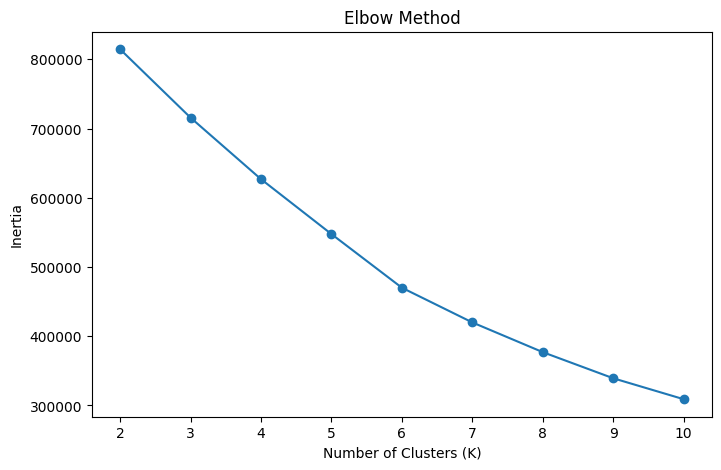

In [4]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

Silhouette Score

In [5]:
scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)

Plot Silhouette Scores

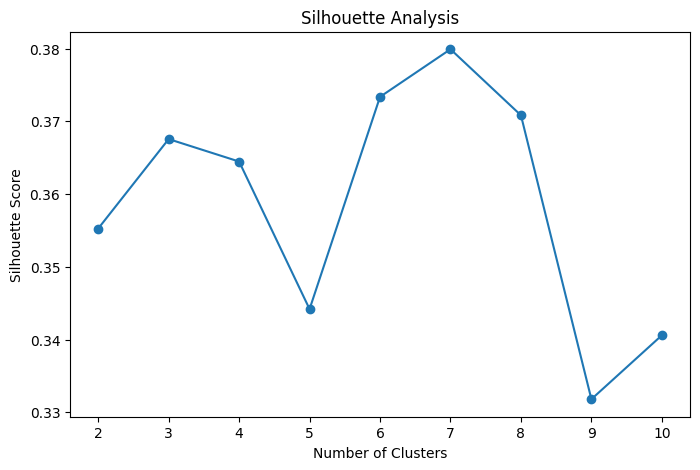

In [6]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.show()

Select the Best Number of Clusters

In [17]:
optimal_k = 6

Train the Final K-Means Model

In [18]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

Add Cluster Labels

In [19]:
clustered_data = X_scaled.copy()

clustered_data["Cluster"] = clusters

clustered_data.head()

,Recency,Frequency,Monetary,Total_Freight,Average_Product_Price,Total_Products,Average_Installments,Preferred_Payment_credit_card,Preferred_Payment_debit_card,Preferred_Payment_voucher,Cluster
0,-0.825322,-0.159817,-0.108908,-0.467153,0.021352,-0.283273,1.904761,0.552748,-0.124605,-0.13807,4
1,-0.805656,-0.159817,-0.287518,-0.604269,-0.561163,-0.283273,-0.709924,0.552748,-0.124605,-0.13807,2
2,1.960741,-0.159817,-0.195605,-0.274228,-0.298244,-0.283273,1.904761,0.552748,-0.124605,-0.13807,4
3,0.544765,-0.159817,-0.261935,-0.259075,-0.523956,-0.283273,0.410655,0.552748,-0.124605,-0.13807,2
4,0.328436,-0.159817,-0.023285,-0.286425,0.284271,-0.283273,1.157708,0.552748,-0.124605,-0.13807,4


Number of Customers in Each Cluster

In [20]:
clustered_data["Cluster"].value_counts().sort_index()

Cluster
0     3154
1    17813
2    55387
3     1427
4    13824
5     1730
Name: count, dtype: int64

Cluster Distribution

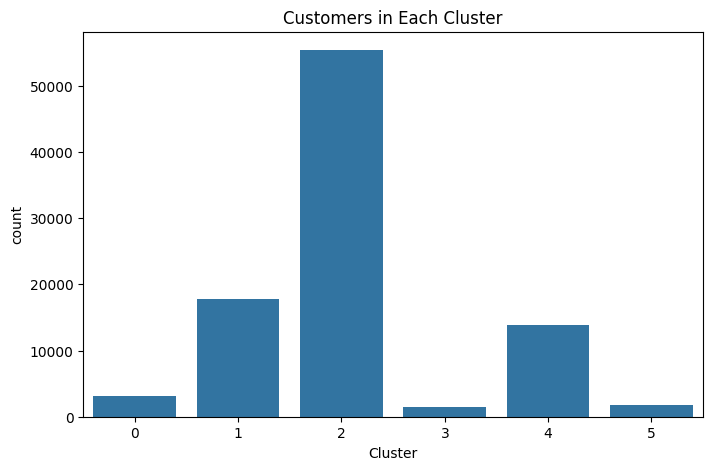

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Cluster",
    data=clustered_data
)

plt.title("Customers in Each Cluster")

plt.show()

Cluster Centers

In [22]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X_scaled.columns
)

centers

,Recency,Frequency,Monetary,Total_Freight,Average_Product_Price,Total_Products,Average_Installments,Preferred_Payment_credit_card,Preferred_Payment_debit_card,Preferred_Payment_voucher
0,-0.106931,4.449945,1.173874,1.496950,-0.081212,2.332795,0.178769,-0.018085,-0.124605,-0.100664
1,0.063303,-0.159817,-0.086395,-0.116908,-0.145087,-0.131523,-0.709924,-1.809142,-0.124605,-0.138070
2,-0.031251,-0.159817,-0.130136,-0.178606,-0.204231,-0.127060,-0.211684,0.552748,-0.124605,-0.138070
3,-0.458723,-0.089437,-0.066316,-0.136734,-0.074250,-0.120868,-0.708899,-1.809142,8.025363,-0.138070
4,0.100800,-0.159817,0.386584,0.436656,1.055944,-0.020683,1.881093,0.533796,-0.124605,-0.138070
5,0.116077,-0.007773,-0.123471,0.810305,-0.202745,1.429312,-0.697412,-1.809142,-0.124605,7.242684


PCA for 2D Visualization

In [23]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

Create PCA DataFrame

In [24]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = clusters

Visualize the Clusters

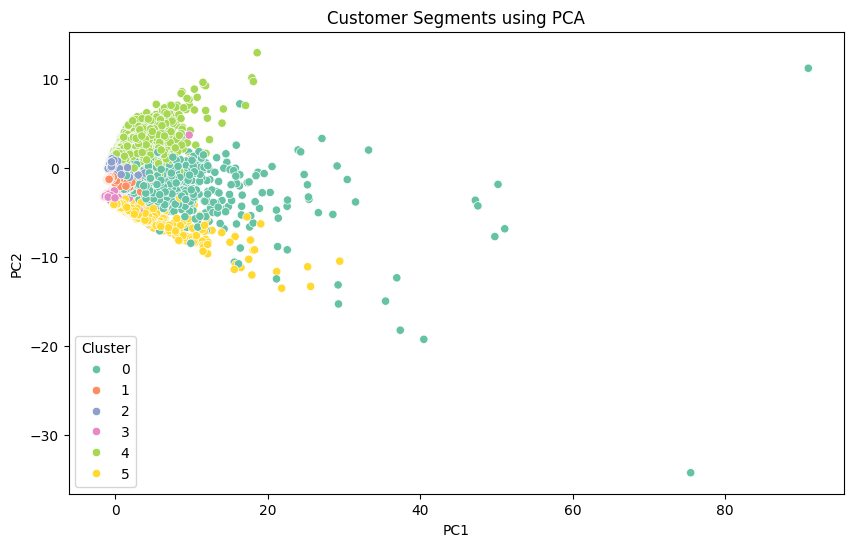

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments using PCA")

plt.show()

Save Clustered Data

In [26]:
clustered_data.to_csv(
    "../datasets/cleaned/customer_segments.csv",
    index=False
)

print("Customer segments saved successfully!")

Customer segments saved successfully!


Save the Model

In [27]:
import joblib

joblib.dump(kmeans, "../models/kmeans.pkl")
print("KMeans model saved successfully!")

KMeans model saved successfully!
